# Perform the clustering tasks

In [5]:
# Define utility functions
from sklearn.cluster import AgglomerativeClustering
import numpy as np
from scipy.cluster.hierarchy import dendrogram
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.metrics import silhouette_score


def find_best_n_clusters(data, min_clusters=2, metric='euclidean', linkage='ward'):
    """
    Finds the optimal number of clusters using the silhouette score.
    
    Parameters:
        data (array-like): Input data for clustering.
        min_clusters (int): Minimum number of clusters to evaluate.
        max_clusters (int): Maximum number of clusters to evaluate.
    
    Returns:
        int: Best number of clusters based on silhouette score.
    """
    best_n = min_clusters
    best_score = -1
    for n in range(min_clusters, data.shape[0] - 2):
        model = AgglomerativeClustering(n_clusters=n, linkage=linkage, metric=metric)
        labels = model.fit_predict(data)
        score = silhouette_score(data, labels)
        if score > best_score:
            best_score = score
            best_n = n
    return best_n


def plot_dendrogram(data,
                    ax,
                    labels,
                    title="Hierarchical Clustering Dendrogram",
                    linkage_="complete",
                    distance_= "euclidean",
                    leaf_rotation=90,
                    leaf_font_size=10,
                    color_threshold=None,
                    show_leaf_counts=True,
                    annotate_above=0,
                    **kwargs):
    """
    Plots a visually enhanced dendrogram from a hierarchical clustering model with consistent colors for each cluster.
    
    Parameters:
        data (array-like): Input data for clustering.
        ax (matplotlib.axes.Axes): Axis to plot on.
        title (str): Title of the dendrogram plot.
        figsize (tuple): Figure size (width, height).
        leaf_rotation (int): Rotation angle for leaf labels.
        leaf_font_size (int): Font size of leaf labels.
        color_threshold (float): Distance threshold for coloring clusters.
        show_leaf_counts (bool): Whether to display leaf counts.
        annotate_above (float): Threshold above which to annotate the dendrogram.
        n_clusters (int): Number of clusters to extract from the dendrogram.
        **kwargs: Additional arguments passed to `dendrogram`.
    """
    model = AgglomerativeClustering(distance_threshold=0,
                                    n_clusters=None,
                                    metric=distance_,
                                    linkage=linkage_)
    model.fit(data)
    
    n_samples = len(model.labels_)
    counts = np.zeros(model.children_.shape[0])
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    model = AgglomerativeClustering(distance_threshold=color_threshold,
                                    metric=distance_, linkage=linkage_, n_clusters=None)
    model.fit(data)
    
    
    # Compute dendrogram and extract leaf labels
    with plt.rc_context({'lines.linewidth': 3}):
        dendro = dendrogram(
            linkage_matrix,
            leaf_rotation=leaf_rotation,
            leaf_font_size=leaf_font_size,
            color_threshold=color_threshold,
            show_leaf_counts=show_leaf_counts,
            # above_threshold_color='gray',
            above_threshold_color='k',
            ax=ax,
            labels=labels,
            **kwargs
        )
                
        if annotate_above > 0:
            for i, d in enumerate(linkage_matrix[:, 2]):
                if d > annotate_above:
                    ax.annotate(f"{d:.2f}", 
                                (i, d), 
                                xytext=(5, 5), 
                                textcoords="offset points",
                                fontsize=9,
                                color="black")

        best_clusters = find_best_n_clusters(data, min_clusters=2, metric=distance_, linkage=linkage_)

        ax.set_title(f"{title}", # \n (Optimum number of clusters: {best_clusters})",
                    fontsize=12,
                    fontweight="semibold")
        ax.set_xlabel("", fontsize=12)
        ax.set_ylabel("Distance", fontsize=12)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

In [6]:
# Load the dataset
import pandas as pd

frequency_df = pd.read_csv("../dataset/frequency.csv")

stylometry_df = pd.read_csv("../dataset/stylometry.csv")

## Study all gospels

/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/294444574.py:109: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


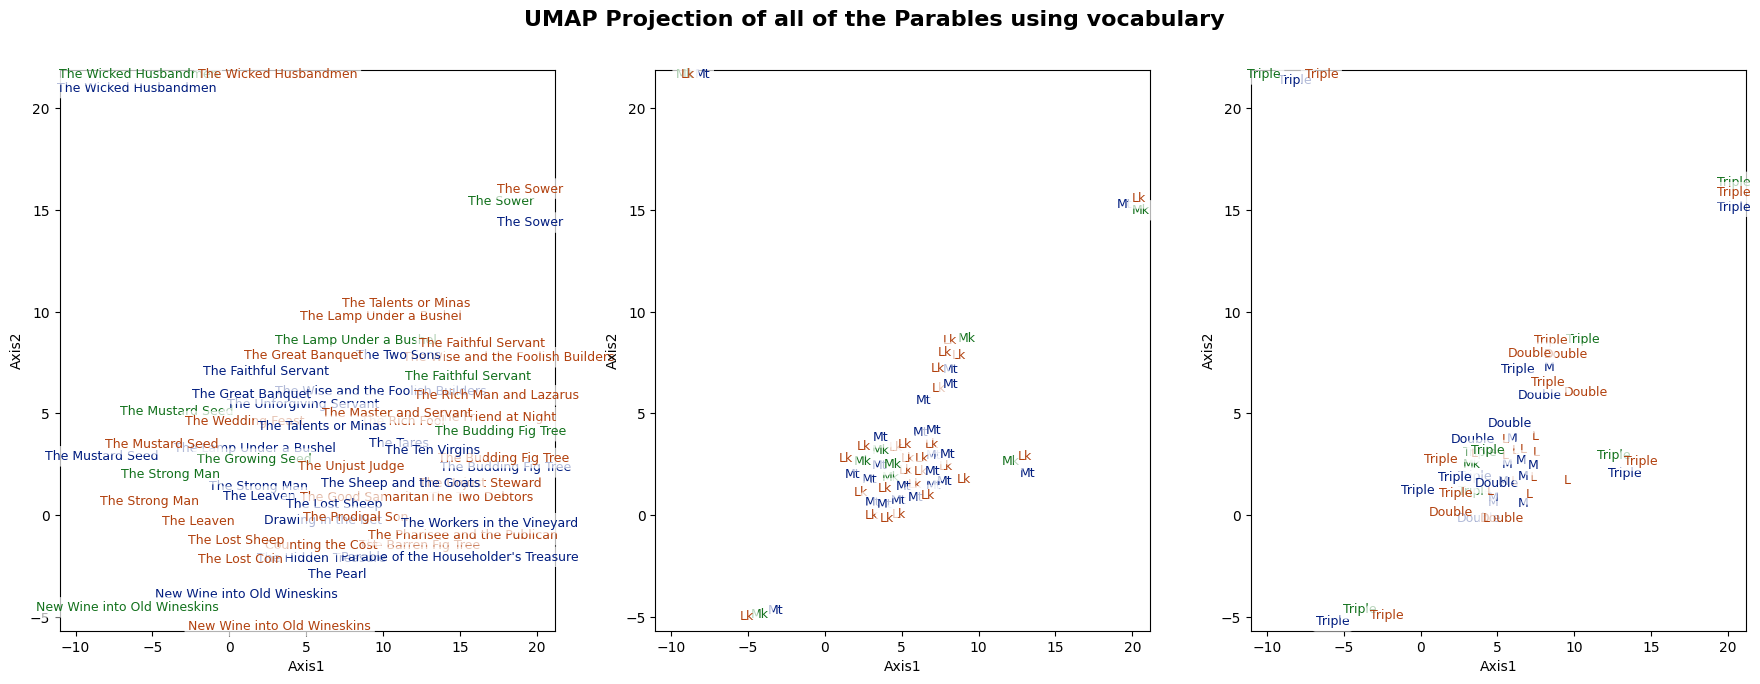

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull
import umap

# Create side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 8), constrained_layout=True)  # One row, three columns

# Apply UMAP
umap_ = umap.UMAP(n_components=2, metric="cosine", n_neighbors=3, random_state=42)
all_df = frequency_df


# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    all_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
all_df["cluster"] = hac.fit_predict(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

unique_labels = all_df["cluster"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))
unique_sources = all_df["source"].unique()
source_palette = dict(zip(unique_sources, sns.color_palette("dark", len(unique_sources))))

unique_books = all_df["book"].unique()

book_palette = dict(zip(unique_books, sns.color_palette("dark", len(unique_books))))


# Perform PCA transformation
umap_components = umap_.fit_transform(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
umap_df = pd.DataFrame(data=umap_components, columns=["Axis1", "Axis2"])
umap_df["parable"] = all_df["parable"].values
umap_df["labels"] = all_df["cluster"].values
umap_df["source"] = all_df["source"].values  # Only used for the second plot
umap_df["book"] = all_df["book"].values  # Only used for the second plot

# Generate a color palette
unique_labels = all_df["cluster"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(umap_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = umap_df["Axis1"].min() - hull_padding, umap_df["Axis1"].max() + hull_padding
y_min, y_max = umap_df["Axis2"].min() - 0.2 * hull_padding, umap_df["Axis2"].max() + 0.2 * hull_padding


# ----------- First plot (labels = parables) -----------
ax = axes[0]
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(umap_df.Axis1[line], umap_df.Axis2[line], umap_df.parable[line],
            color=book_palette[umap_df.book[line]],
            horizontalalignment='left', size=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(umap_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Parables", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = books) -----------
ax = axes[1]
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(umap_df.Axis1[line], umap_df.Axis2[line], umap_df.book[line],
            horizontalalignment='left', size=9, color=book_palette[umap_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(umap_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Books", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# ----------- Third plot (labels = sources) -----------
ax = axes[2]
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(umap_df.Axis1[line], umap_df.Axis2[line], umap_df.source[line],
            horizontalalignment='left', size=9, 
                        color=book_palette[umap_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(umap_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Sources", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# Save and show the figure
plt.suptitle(f"UMAP Projection of all of the Parables using vocabulary", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()
plt.savefig("figures/all_vocabulary_pca_three_way.png", dpi=600)
plt.show()


/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/3922585357.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


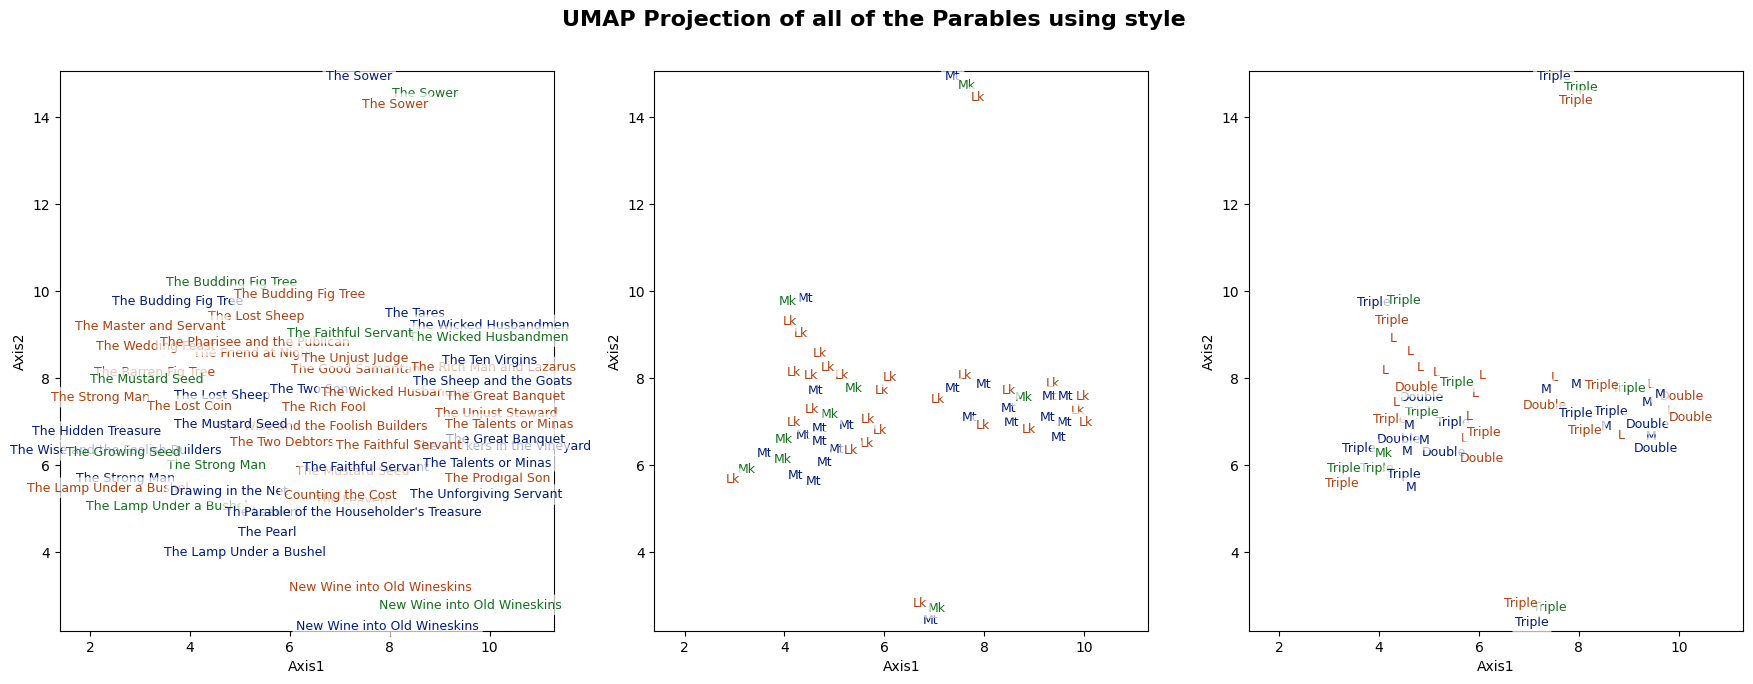

In [ ]:
from sklearn.preprocessing import StandardScaler


import umap

scaler = StandardScaler()
# Create side-by-side subplots with three columns
fig, axes = plt.subplots(1, 3, figsize=(22, 8), constrained_layout=True)  # One row, three columns

# Apply UMAP
umap_ = umap.UMAP(n_components=2, metric="manhattan", n_neighbors=4, random_state=42)

all_df = scaler.fit_transform(stylometry_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
all_df = pd.DataFrame(data=all_df, columns=stylometry_df.columns[4:])
all_df["parable"] = frequency_df["parable"].values
all_df["book"] = frequency_df["book"].values
all_df["source"] = frequency_df["source"].values
all_df["source_interpretation"] = frequency_df["source_interpretation"].values

# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    all_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
all_df["cluster"] = hac.fit_predict(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))


unique_labels = all_df["cluster"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))
unique_sources = all_df["source"].unique()
source_palette = dict(zip(unique_sources, sns.color_palette("dark", len(unique_sources))))
unique_books = all_df["book"].unique()
book_palette = dict(zip(unique_books, sns.color_palette("dark", len(unique_books))))


# Perform PCA transformation
umap_components = umap_.fit_transform(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
umap_df = pd.DataFrame(data=umap_components, columns=["Axis1", "Axis2"])
umap_df["parable"] = all_df["parable"].values
umap_df["labels"] = all_df["cluster"].values
umap_df["source"] = all_df["source"].values  # Only used for the second plot
umap_df["book"] = all_df["book"].values  # Only used for the second plot

selected_number_clusters = find_best_n_clusters(
    umap_df.drop(columns=["parable", "book", "source", "labels"]),
    min_clusters=2,
    metric='cosine', 
    linkage='average'
)

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(umap_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = umap_df["Axis1"].min() - hull_padding, umap_df["Axis1"].max() + hull_padding
y_min, y_max = umap_df["Axis2"].min() - 0.2 * hull_padding, umap_df["Axis2"].max() + 0.2 * hull_padding


# ----------- First plot (labels = parables) -----------
ax = axes[0]
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(umap_df.Axis1[line], umap_df.Axis2[line], umap_df.parable[line],
            color=book_palette[umap_df.book[line]],
            horizontalalignment='left', size=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(umap_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Parables", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = books) -----------
ax = axes[1]
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(umap_df.Axis1[line], umap_df.Axis2[line], umap_df.book[line],
            horizontalalignment='left', size=9, color=book_palette[umap_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(umap_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Books", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# ----------- Third plot (labels = sources) -----------
ax = axes[2]
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(umap_df.Axis1[line], umap_df.Axis2[line], umap_df.source[line],
            horizontalalignment='left', size=9, color=book_palette[umap_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(umap_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Sources", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# Save and show the figure
plt.suptitle(f"UMAP Projection of all of the Parables using style", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()
plt.savefig("figures/all_style_pca_three_way.png", dpi=600)
plt.show()

/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


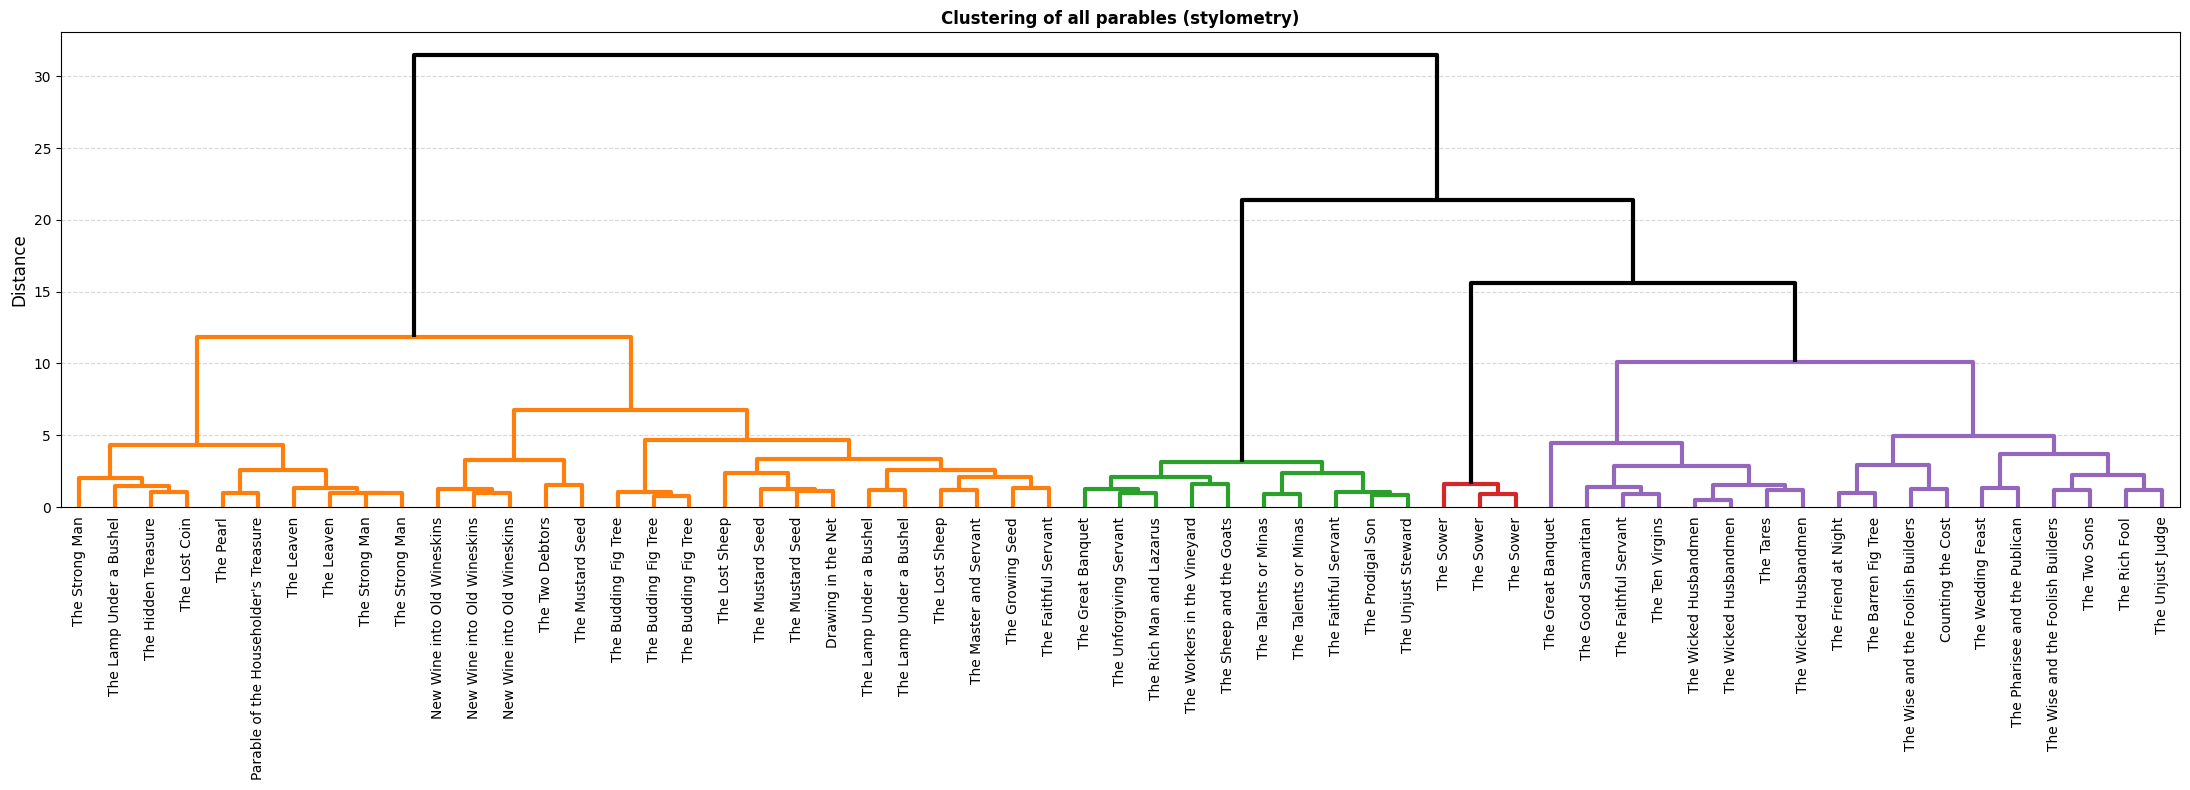

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import umap  # Assuming umap is used in the plot_dendrogram function

# Set up the figure with a 2x1 layout for the right pane
fig, axes = plt.subplots(1, 1, figsize=(22, 8)) # Adjusted figsize for better vertical display

# ---------------- Compute PCA for both datasets ----------------
uamp_style = umap.UMAP(n_components=15, metric="manhattan", n_neighbors=5, random_state=42)  # Use 15 principal components
umap_stylometry = uamp_style.fit_transform(stylometry_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# ---------------- Second dendrogram (Stylometry - Parables) ----------------
plot_dendrogram(
    umap_stylometry,  # PCA-transformed data
    axes,  # First row
    labels=stylometry_df.parable.values,
    title="Clustering of all parables (stylometry)",
    linkage_="complete",
    distance_="manhattan",
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=12,
    show_leaf_counts=True,
    annotate_above=0,
)


# Adjust layout and add a super title
plt.tight_layout()
#plt.suptitle("Cluster Analysis of All Parables", fontweight='bold', fontsize=16, y=1.05)


plt.savefig("figures/all_dendrograms.png", dpi=600)

plt.show()

## Study on the triple tradition

### Vocabulary

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/1232935208.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df["cluster"] = hac.fit_predict(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


21 [ 0.53112769 -0.76341671]
22 [0.49442949 0.33524454]
21 [ 0.18902991 -0.38894932]
22 [0.34330405 0.51654113]


/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/1232935208.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


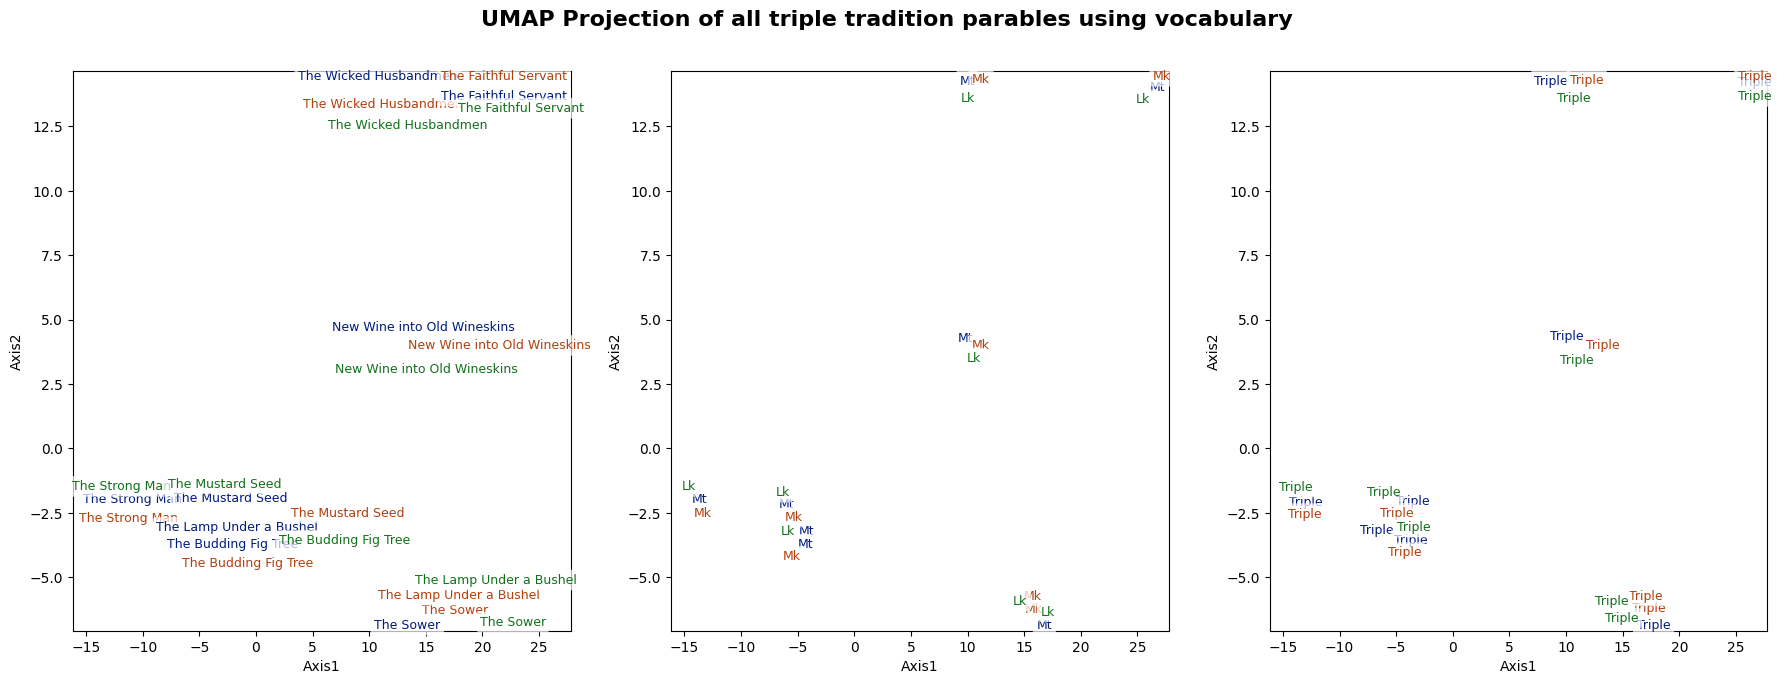

In [16]:
# Perform PCA on the vocabulary matrix
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import ConvexHull
from sklearn.manifold import TSNE

# Create side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 8), constrained_layout=True)  # One row, three columns

# Apply UMAP
umap_ = umap.UMAP(n_components=2, n_neighbors=3, min_dist=0.1, metric="cosine")
all_df = frequency_df[frequency_df["source"] == "Triple"]



# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    all_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
all_df["cluster"] = hac.fit_predict(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

unique_labels = all_df["cluster"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))
unique_sources = all_df["source"].unique()
source_palette = dict(zip(unique_sources, sns.color_palette("dark", len(unique_sources))))
unique_books = all_df["book"].unique()
book_palette = dict(zip(unique_books, sns.color_palette("dark", len(unique_books))))


# Perform PCA transformation
umap_components = umap_.fit_transform(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
umap_df = pd.DataFrame(data=umap_components, columns=["Axis1", "Axis2"])
umap_df["parable"] = all_df["parable"].values
umap_df["labels"] = all_df["cluster"].values
umap_df["source"] = all_df["source"].values  # Only used for the second plot
umap_df["book"] = all_df["book"].values  # Only used for the second plot

# Generate a color palette
unique_labels = all_df["cluster"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(umap_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = umap_df["Axis1"].min() - hull_padding, umap_df["Axis1"].max() + hull_padding
y_min, y_max = umap_df["Axis2"].min() - 0.2 * hull_padding, umap_df["Axis2"].max() + 0.2 * hull_padding


# ----------- First plot (labels = parables) -----------
ax = axes[0]
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(umap_df.Axis1[line], umap_df.Axis2[line], umap_df.parable[line],
            color=book_palette[umap_df.book[line]],
            horizontalalignment='left', size=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(umap_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Parables", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = books) -----------
ax = axes[1]
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(umap_df.Axis1[line], umap_df.Axis2[line], umap_df.book[line],
            horizontalalignment='left', size=9, color=book_palette[umap_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(umap_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Books", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# ----------- Third plot (labels = sources) -----------
ax = axes[2]
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(umap_df.Axis1[line], umap_df.Axis2[line], umap_df.source[line],
            horizontalalignment='left', size=9, 
                        color=book_palette[umap_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(umap_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Sources", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# Save and show the figure
plt.suptitle(f"UMAP Projection of all triple tradition parables using vocabulary", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()
plt.savefig("figures/all_vocabulary_pca_triple.png", dpi=600)
plt.show()


### Stylometry

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/171513038.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df["cluster"] = hac.fit_predict(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


1 [ 0.82200006 -0.93099067]
2 [0.06869384 0.36152583]
1 [-0.8972006  -0.37758626]
2 [0.70495696 0.98341708]
1 [-0.55401536 -0.19179072]
2 [ 0.29771442 -0.79527775]
1 [-0.86448868  0.47422323]
2 [0.96759814 0.32168733]
1 [0.1679225  0.73054153]
2 [-0.63582224  0.60598391]
1 [-0.48738769 -0.38189588]
2 [-0.4528799   0.90568866]
1 [-0.78436257 -0.14745301]
2 [0.89139649 0.64663154]
1 [-0.09416434 -0.89700321]
2 [-0.74641045  0.25845624]
1 [0.98392811 0.71522988]
2 [-0.36069219 -0.70132507]
1 [-0.82938357  0.24674529]
2 [0.64433712 0.64823179]
1 [-0.36442198 -0.63954023]
2 [ 0.08278543 -0.11658959]
1 [-0.63414291 -0.50018426]
2 [-0.07544645 -0.46205463]
1 [ 0.14669092 -0.98684992]
2 [0.65590038 0.88830692]
1 [-0.23489159  0.73662744]
2 [-0.61354466  0.5397443 ]
1 [ 0.57412552 -0.71236549]
2 [0.03714823 0.28775886]
1 [0.29619183 0.91808861]
2 [ 0.32316209 -0.85677318]
1 [ 0.10089522 -0.9006106 ]
2 [ 0.20727642 -0.29517513]
1 [ 0.38708903 -0.7704022 ]
2 [ 0.24236351 -0.697293  ]
1 [-0.883490

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/171513038.py:101: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


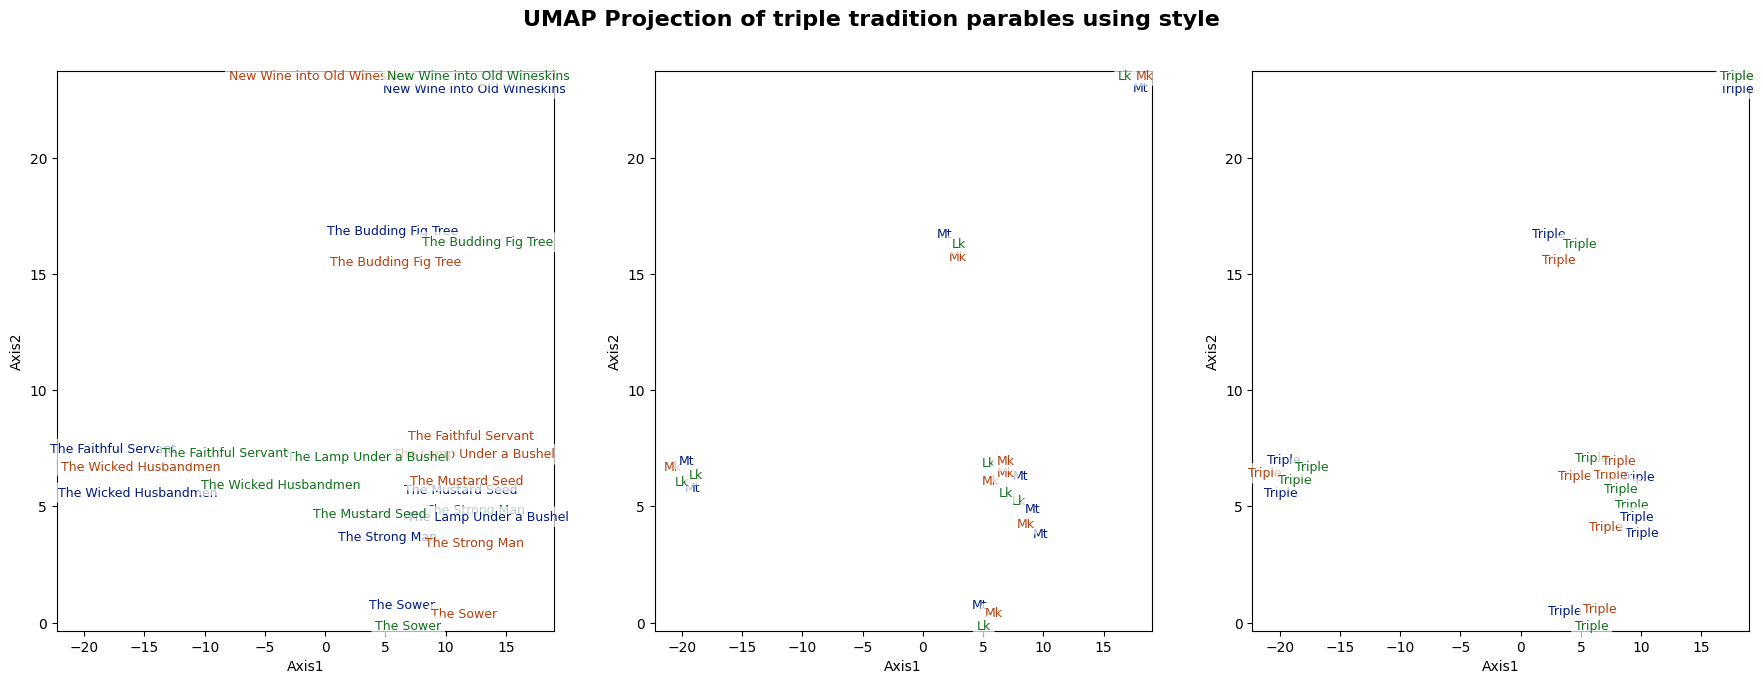

In [ ]:
# Create side-by-side subplots with three columns
fig, axes = plt.subplots(1, 3, figsize=(22, 8), constrained_layout=True)  # One row, three columns

# Apply UMAP
umap_ = umap.UMAP(n_components=2, n_neighbors=3, min_dist=0.1, metric="euclidean")
all_df = stylometry_df[stylometry_df["source"] == "Triple"]

# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    all_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
all_df["cluster"] = hac.fit_predict(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))


unique_labels = all_df["cluster"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))
unique_sources = all_df["source"].unique()
source_palette = dict(zip(unique_sources, sns.color_palette("dark", len(unique_sources))))
unique_books = all_df["book"].unique()
book_palette = dict(zip(unique_books, sns.color_palette("dark", len(unique_books))))


# Perform PCA transformation
umap_components = umap_.fit_transform(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
umap_df = pd.DataFrame(data=umap_components, columns=["Axis1", "Axis2"])
umap_df["parable"] = all_df["parable"].values
umap_df["labels"] = all_df["cluster"].values
umap_df["source"] = all_df["source"].values  # Only used for the second plot
umap_df["book"] = all_df["book"].values  # Only used for the second plot

selected_number_clusters = find_best_n_clusters(
    umap_df.drop(columns=["parable", "book", "source", "labels"]),
    min_clusters=2,
    metric='cosine', 
    linkage='average'
)

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(umap_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = umap_df["Axis1"].min() - hull_padding, umap_df["Axis1"].max() + hull_padding
y_min, y_max = umap_df["Axis2"].min() - 0.2 * hull_padding, umap_df["Axis2"].max() + 0.2 * hull_padding


# ----------- First plot (labels = parables) -----------
ax = axes[0]
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(umap_df.Axis1[line], umap_df.Axis2[line], umap_df.parable[line],
            color=book_palette[umap_df.book[line]],
            horizontalalignment='left', size=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(umap_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Parables", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = books) -----------
ax = axes[1]
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(umap_df.Axis1[line], umap_df.Axis2[line], umap_df.book[line],
            horizontalalignment='left', size=9, color=book_palette[umap_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(umap_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Books", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# ----------- Third plot (labels = sources) -----------
ax = axes[2]
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(umap_df.Axis1[line], umap_df.Axis2[line], umap_df.source[line],
            horizontalalignment='left', size=9, color=book_palette[umap_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(umap_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Sources", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# Save and show the figure
plt.suptitle(f"UMAP Projection of triple tradition parables using style", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()
plt.savefig("figures/all_style_pca_triple.png", dpi=600)
plt.show()


In [ ]:
### Compute the vocabulary and stylistic distance between parables from the triple tradition

# Compute the distance between parabolas of the same name

from sklearn.metrics.pairwise import manhattan_distances, cosine_distances

distances = []

for parable, source in zip(frequency_df.drop_duplicates("parable").parable, frequency_df.drop_duplicates("parable").source):
    if source == "Triple":
        mt = frequency_df[(frequency_df.parable == parable) & (frequency_df.book == "Mt")]
        mk = frequency_df[(frequency_df.parable == parable) & (frequency_df.book == "Mk")]
        lk = frequency_df[(frequency_df.parable == parable) & (frequency_df.book == "Lk")]
        distance_mt_mk = cosine_distances(mt.drop(columns=["parable", "book", "source", "source_interpretation"]), mk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distance_mt_lk = cosine_distances(mt.drop(columns=["parable", "book", "source", "source_interpretation"]), lk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distance_mk_lk = cosine_distances(mk.drop(columns=["parable", "book", "source", "source_interpretation"]), lk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distances.append(
            {
                "parable": parable,
                "tradition": "Triple",
                "type": "vocabulary",
                "distance_mt_mk": distance_mt_mk,
                "distance_mt_lk": distance_mt_lk,
                "distance_mk_lk": distance_mk_lk
            }
        )

for parable, source in zip(stylometry_df.drop_duplicates("parable").parable, stylometry_df.drop_duplicates("parable").source):
    if source == "Triple":
        mt = stylometry_df[(stylometry_df.parable == parable) & (stylometry_df.book == "Mt")]
        mk = stylometry_df[(stylometry_df.parable == parable) & (stylometry_df.book == "Mk")]
        lk = stylometry_df[(stylometry_df.parable == parable) & (stylometry_df.book == "Lk")]
        distance_mt_mk = manhattan_distances(mt.drop(columns=["parable", "book", "source", "source_interpretation"]), mk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distance_mt_lk = manhattan_distances(mt.drop(columns=["parable", "book", "source", "source_interpretation"]), lk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distance_mk_lk = manhattan_distances(mk.drop(columns=["parable", "book", "source", "source_interpretation"]), lk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distances.append(
            {
                "parable": parable,
                "tradition": "Triple",
                "type": "style",
                "distance_mt_mk": distance_mt_mk,
                "distance_mt_lk": distance_mt_lk,
                "distance_mk_lk": distance_mk_lk
            }
        )

In [ ]:
distances = pd.DataFrame(distances)
print(distances[distances.type == "style"].drop(["tradition","type"], axis=1).sort_values(["distance_mt_mk"], ascending=False).to_latex(float_format="%.1f", index=False))

\begin{tabular}{lrrr}
\toprule
parable & distance_mt_mk & distance_mt_lk & distance_mk_lk \\
\midrule
The Faithful Servant & 1241.0 & 1275.3 & 2434.4 \\
The Lamp Under a Bushel & 499.3 & 437.8 & 324.9 \\
The Wicked Husbandmen & 403.9 & 475.1 & 358.6 \\
The Sower & 285.5 & 344.8 & 407.9 \\
The Mustard Seed & 237.1 & 233.0 & 339.6 \\
New Wine into Old Wineskins & 160.8 & 230.9 & 209.7 \\
The Budding Fig Tree & 88.2 & 140.9 & 119.7 \\
The Strong Man & 46.7 & 241.4 & 226.8 \\
\bottomrule
\end{tabular}



In [ ]:
print(distances[distances.type == "vocabulary"].drop(["tradition","type"], axis=1).sort_values(["distance_mt_mk"], ascending=False).to_latex(float_format="%.2f", index=False))

\begin{tabular}{lrrr}
\toprule
parable & distance_mt_mk & distance_mt_lk & distance_mk_lk \\
\midrule
The Lamp Under a Bushel & 0.27 & 0.18 & 0.14 \\
The Faithful Servant & 0.17 & 0.12 & 0.30 \\
The Wicked Husbandmen & 0.14 & 0.29 & 0.26 \\
The Sower & 0.11 & 0.32 & 0.34 \\
New Wine into Old Wineskins & 0.05 & 0.13 & 0.11 \\
The Budding Fig Tree & 0.03 & 0.09 & 0.11 \\
The Mustard Seed & 0.03 & 0.02 & 0.03 \\
The Strong Man & 0.01 & 0.08 & 0.08 \\
\bottomrule
\end{tabular}



In [ ]:
### Compute the vocabulary and stylistic distance between parables from the triple tradition
from sklearn.metrics.pairwise import manhattan_distances, cosine_distances

distances = []

for parable, source in zip(frequency_df.drop_duplicates("parable").parable, frequency_df.drop_duplicates("parable").source):
    if source == "Double":
        mt = frequency_df[(frequency_df.parable == parable) & (frequency_df.book == "Mt")]
        lk = frequency_df[(frequency_df.parable == parable) & (frequency_df.book == "Lk")]
        distance_mt_lk = cosine_distances(mt.drop(columns=["parable", "book", "source", "source_interpretation"]), lk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distances.append(
            {
                "parable": parable,
                "tradition": "Triple",
                "type": "vocabulary",
                "distance_mt_lk": distance_mt_lk,
            }
        )

for parable, source in zip(stylometry_df.drop_duplicates("parable").parable, stylometry_df.drop_duplicates("parable").source):
    if source == "Double":
        mt = stylometry_df[(stylometry_df.parable == parable) & (stylometry_df.book == "Mt")]
        lk = stylometry_df[(stylometry_df.parable == parable) & (stylometry_df.book == "Lk")]
        distance_mt_lk = manhattan_distances(mt.drop(columns=["parable", "book", "source", "source_interpretation"]), lk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distances.append(
            {
                "parable": parable,
                "tradition": "Triple",
                "type": "style",
                "distance_mt_lk": distance_mt_lk,
            }
        )

In [ ]:
distances = pd.DataFrame(distances)

distances[distances.type == "style"].drop(["tradition","type","parable"], axis=1).median()

distance_mt_lk    489.261032
dtype: float64

In [ ]:
distances[distances.type == "vocabulary"].drop(["tradition","type","parable"], axis=1).mean()

distance_mt_lk    0.496939
dtype: float64

## Study Matthew's Gospel

### Vocabulary

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/916955610.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T

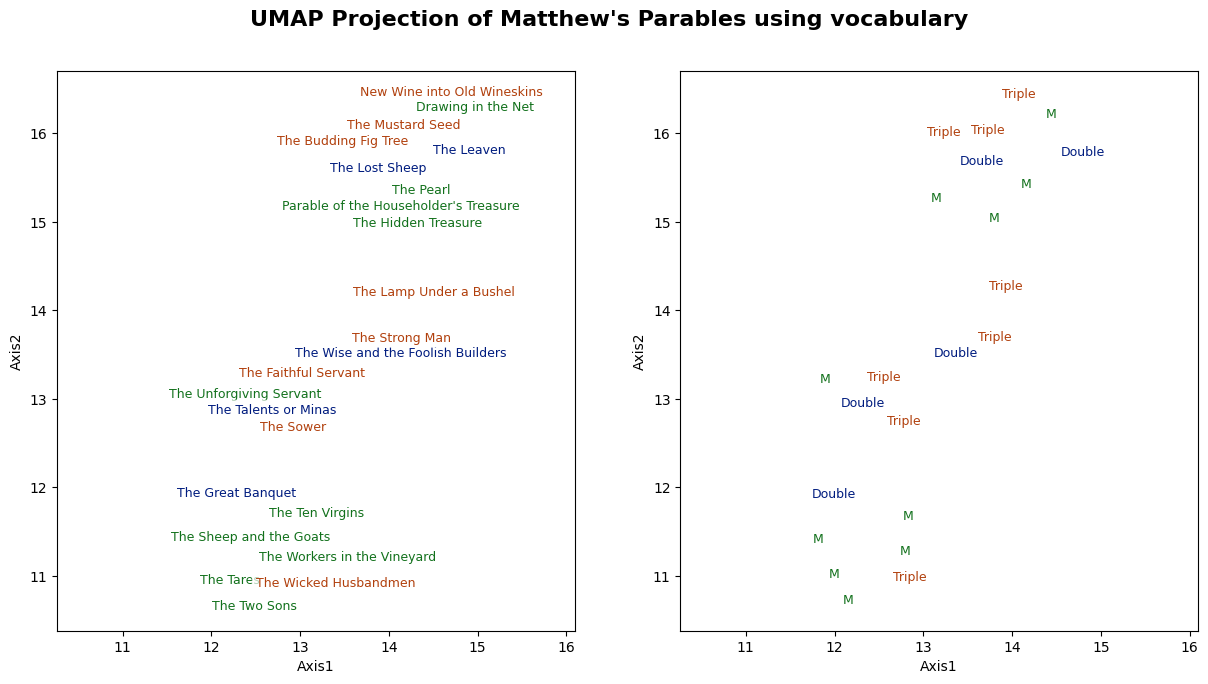

In [ ]:
# Perform PCA on the vocabulary matrix
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import ConvexHull

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 8), constrained_layout=True)  # One row, two columns

# Apply UMAP
umap_ = umap.UMAP(n_components=2, n_neighbors=5, min_dist=0.1, metric="cosine", random_state=40)
mt_df = frequency_df[frequency_df["book"] == "Mt"]

# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Perform PCA transformation
umap_components = umap_.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
umap_df = pd.DataFrame(data=umap_components, columns=["Axis1", "Axis2"])
umap_df["parable"] = mt_df["parable"].values
umap_df["labels"] = mt_df["cluster"].values
umap_df["source"] = mt_df["source"].values  # Only used for the second plot

# Generate a color palette
unique_labels = mt_df["source"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(umap_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = umap_df["Axis1"].min() - hull_padding, umap_df["Axis1"].max() + hull_padding
y_min, y_max = umap_df["Axis2"].min() - 0.2 * hull_padding, umap_df["Axis2"].max() + 0.2 * hull_padding

# ----------- First plot (labels = parables) -----------
ax = axes[0]
# Change alpha to 1 so that points are visible
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(umap_df.shape[0]):
    texts.append(ax.text(umap_df.Axis1[line], umap_df.Axis2[line],
                         umap_df.parable[line], horizontalalignment='left',
                         size=9, 
                         color=palette[umap_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = sources) -----------
ax = axes[1]
# Change alpha to 1 so that points are visible
p1 = sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(umap_df.shape[0]):
    texts.append(p1.text(umap_df.Axis1[line], umap_df.Axis2[line],
                         umap_df.source[line], horizontalalignment='left',
                         size=9, color=palette[umap_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1))

# Save and show the figure
plt.suptitle(f"UMAP Projection of Matthew's Parables using vocabulary", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()

plt.savefig("figures/mt_vocabulary_pca_side_by_side.png", dpi=600)

plt.show()



In [23]:
print(mt_df.sort_values(by="cluster")[["cluster", "parable", "source"]].to_latex(index=False))

\begin{tabular}{rll}
\toprule
cluster & parable & source \\
\midrule
0 & The Wise and the Foolish Builders & Double \\
0 & The Ten Virgins & M \\
0 & The Faithful Servant & Triple \\
0 & The Budding Fig Tree & Triple \\
0 & The Great Banquet & Double \\
0 & The Wicked Husbandmen & Triple \\
0 & The Two Sons & M \\
0 & The Workers in the Vineyard & M \\
0 & The Unforgiving Servant & M \\
0 & The Lost Sheep & Double \\
0 & The Talents or Minas & Double \\
0 & Parable of the Householder's Treasure & M \\
0 & The Pearl & M \\
0 & The Hidden Treasure & M \\
0 & The Leaven & Double \\
0 & The Mustard Seed & Triple \\
0 & The Tares & M \\
0 & The Lamp Under a Bushel & Triple \\
0 & The Strong Man & Triple \\
0 & New Wine into Old Wineskins & Triple \\
0 & Drawing in the Net & M \\
0 & The Sheep and the Goats & M \\
1 & The Sower & Triple \\
\bottomrule
\end{tabular}



### Stylometry study (Matthew)

/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


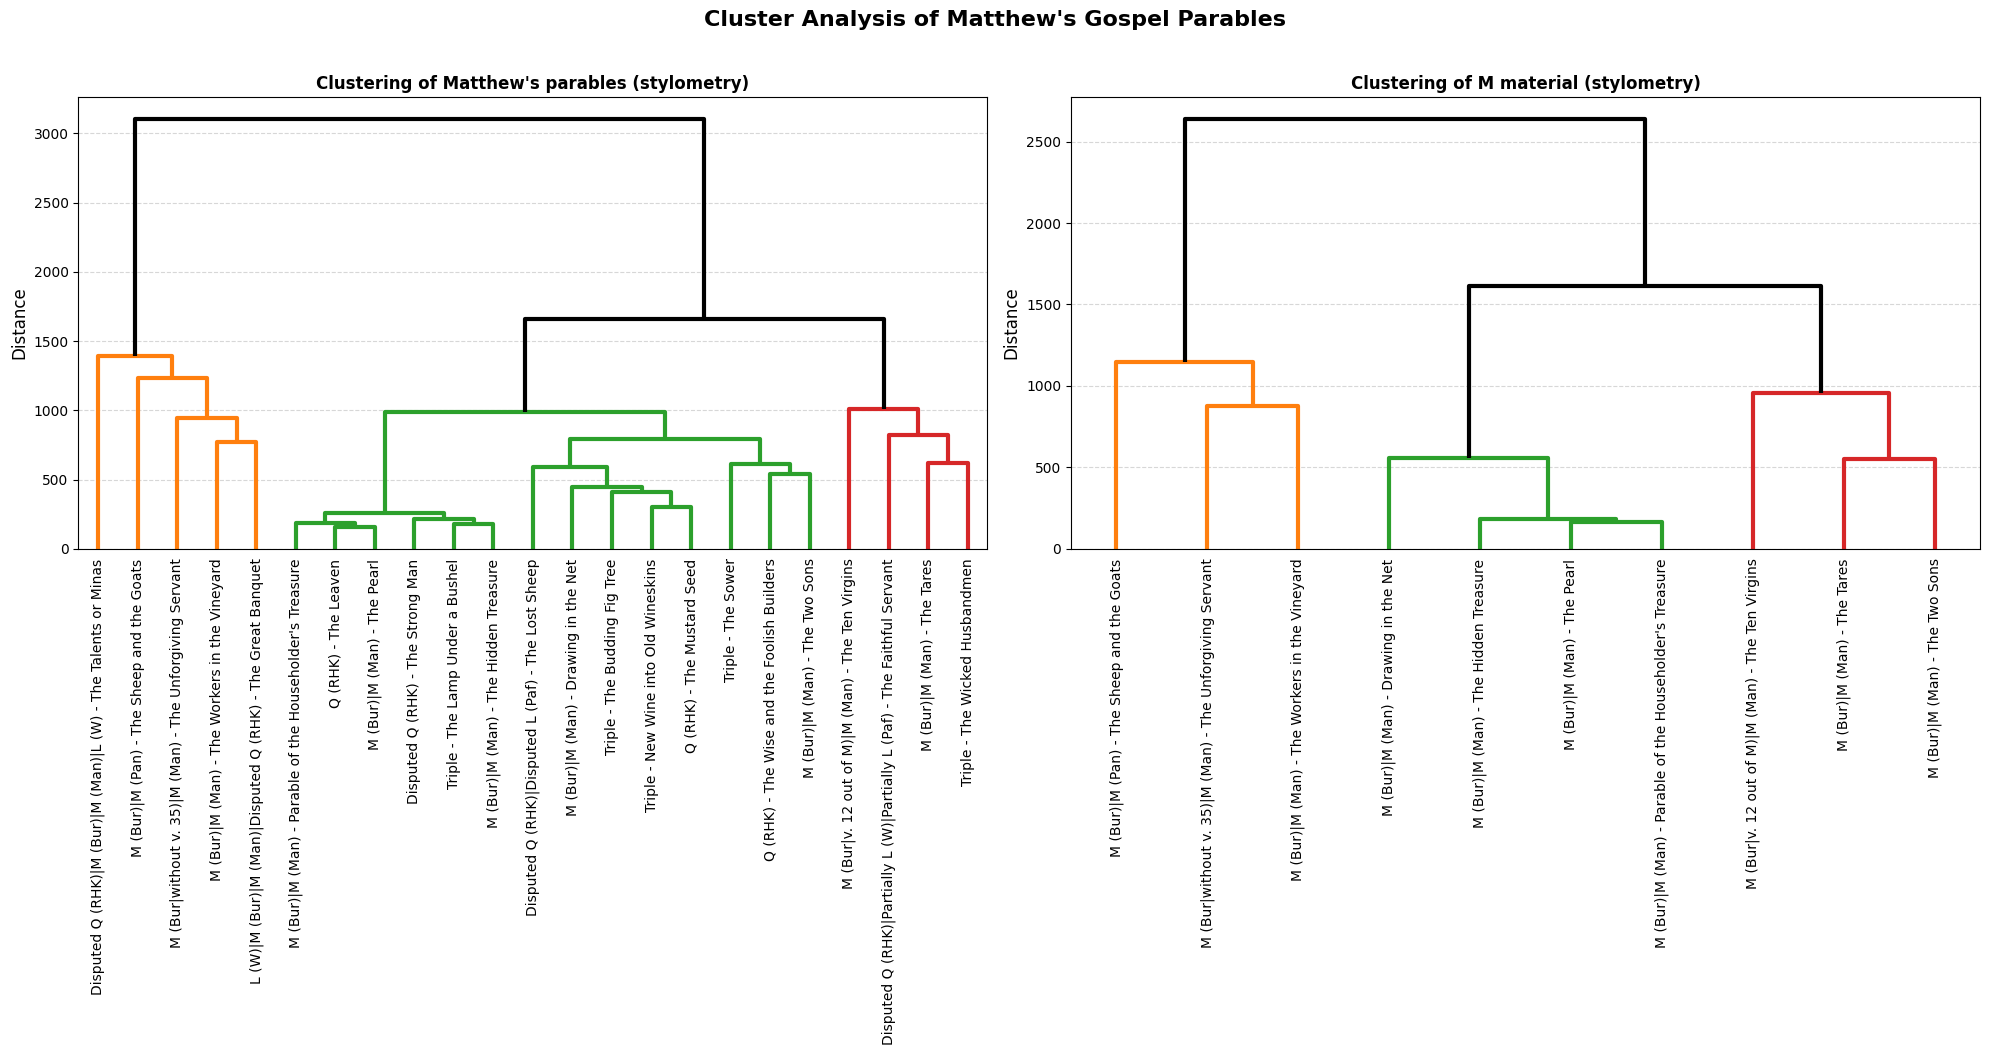

In [30]:
import matplotlib.pyplot as plt

# Your stylometry_df should be defined already

# Set up the figure with two subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# First dendrogram (Clustering of Matthew's parables (stylometry))
mt_df = stylometry_df[(stylometry_df["book"] == "Mt")]
umap_ = umap.UMAP(n_components=10, n_neighbors=5, min_dist=0.1, metric="euclidean", random_state=40)
umap_components = umap_.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Plot the first dendrogram (now showing "Clustering of Matthew's parables (stylometry)")
plot_dendrogram(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    ax[0],  # Use the first subplot (ax[0])
    labels=[f"{"|".join(source_interpretation.replace("[", "").replace("]", "").replace("'", "").split(", ")[1:])} - {label}" if source_interpretation != "['Triple']" else f"Triple - {label}" for label, source_interpretation in zip(mt_df.parable.values, mt_df.source_interpretation.values)],
    title="Clustering of Matthew's parables (stylometry)",
    linkage_="complete",
    distance_="manhattan",
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=1500,
    show_leaf_counts=True,
    annotate_above=0,
)

# Second dendrogram (Clustering of M material)
mt_df = stylometry_df[(stylometry_df["book"] == "Mt") & (stylometry_df["source"] == "M")]
umap_ = umap.UMAP(n_components=5, n_neighbors=5, min_dist=0.1, metric="euclidean", random_state=40)
umap_components = umap_.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Plot the second dendrogram (now showing "Clustering of M material")
plot_dendrogram(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    ax[1],  # Use the second subplot (ax[1])
    labels=[f"{"|".join(source_interpretation.replace("[", "").replace("]", "").replace("'", "").split(", ")[1:])} - {label}" if source_interpretation != "['Triple']" else f"Triple - {label}" for label, source_interpretation in zip(mt_df.parable.values, mt_df.source_interpretation.values)],
    title="Clustering of M material (stylometry)",
    linkage_="complete",
    distance_="manhattan",
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=1500
,
    show_leaf_counts=True,
    annotate_above=0,
)

plt.tight_layout()  # Adjust layout for better spacing
plt.suptitle("Cluster Analysis of Matthew's Gospel Parables", fontweight='bold', fontsize=16, y=1.05)

plt.savefig("figures/mt_stylometry_dendrograms.png", dpi=1000)
plt.show()



/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/2673926668.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/

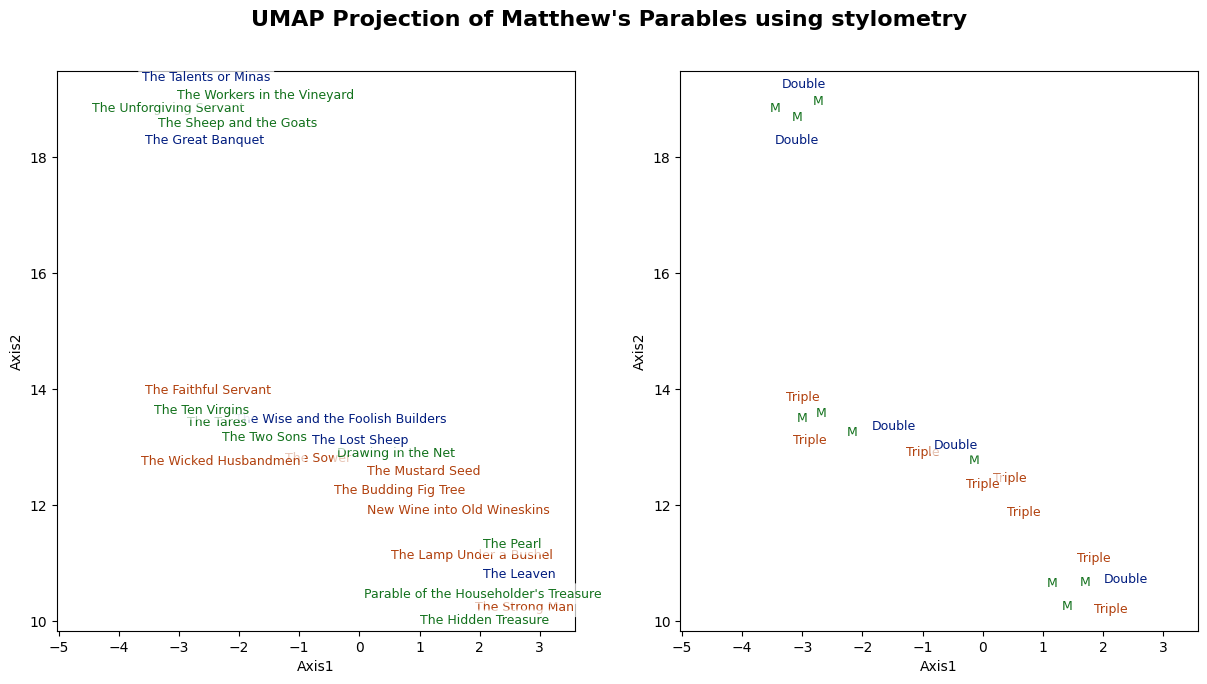

In [31]:
# Perform PCA on the vocabulary matrix
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 8), constrained_layout=True)  # One row, two columns

# Apply UMAP
umap_ = umap.UMAP(n_components=2, n_neighbors=5, min_dist=0.1, metric="euclidean", random_state=42)
mt_df = stylometry_df[stylometry_df["book"] == "Mt"]

# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Perform PCA transformation
umap_components = umap_.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
umap_df = pd.DataFrame(data=umap_components, columns=["Axis1", "Axis2"])
umap_df["parable"] = mt_df["parable"].values
umap_df["labels"] = mt_df["cluster"].values
umap_df["source"] = mt_df["source"].values  # Only used for the second plot

# Generate a color palette
unique_labels = mt_df["source"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(umap_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = umap_df["Axis1"].min() - hull_padding, umap_df["Axis1"].max() + hull_padding
y_min, y_max = umap_df["Axis2"].min() - 0.2 * hull_padding, umap_df["Axis2"].max() + 0.2 * hull_padding

# ----------- First plot (labels = parables) -----------
ax = axes[0]
# Change alpha to 1 so that points are visible
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(umap_df.shape[0]):
    texts.append(ax.text(umap_df.Axis1[line], umap_df.Axis2[line],
                         umap_df.parable[line], horizontalalignment='left',
                         size=9, 
                         color=palette[umap_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = sources) -----------
ax = axes[1]
# Change alpha to 1 so that points are visible
p1 = sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(umap_df.shape[0]):
    texts.append(p1.text(umap_df.Axis1[line], umap_df.Axis2[line],
                         umap_df.source[line], horizontalalignment='left',
                         size=9, 
                         color=palette[umap_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1))

# Save and show the figure
plt.suptitle(f"UMAP Projection of Matthew's Parables using stylometry", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()

plt.savefig("figures/mt_stylometry_pca_side_by_side.png", dpi=600)

plt.show()



In [32]:
mt_df = stylometry_df[(stylometry_df["book"] == "Mt")]

selected_number_clusters = find_best_n_clusters(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2, metric='euclidean', linkage='average')

hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='complete', metric='manhattan')
hac.fit(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
mt_df["cluster"] = hac.labels_

print(mt_df.sort_values(by="cluster")[["cluster", "parable", "source", "source_interpretation"]].to_latex(index=False))

\begin{tabular}{rlll}
\toprule
cluster & parable & source & source_interpretation \\
\midrule
0 & The Wise and the Foolish Builders & Double & ['Double', 'Q (RHK)'] \\
0 & The Ten Virgins & M & ['M', 'M (Bur, v. 12 out of M)', 'M (Man)'] \\
0 & The Faithful Servant & Triple & ['Triple', 'Disputed Q (RHK)', 'Partially L (W)', 'Partially L (Paf)'] \\
0 & The Budding Fig Tree & Triple & ['Triple'] \\
0 & The Wicked Husbandmen & Triple & ['Triple'] \\
0 & The Two Sons & M & ['M', 'M (Bur)', 'M (Man)'] \\
0 & The Lost Sheep & Double & ['Double', 'Disputed Q (RHK)', 'Disputed L (Paf)'] \\
0 & Drawing in the Net & M & ['M', 'M (Bur)', 'M (Man)'] \\
0 & The Pearl & M & ['M', 'M (Bur)', 'M (Man)'] \\
0 & Parable of the Householder's Treasure & M & ['M', 'M (Bur)', 'M (Man)'] \\
0 & The Leaven & Double & ['Double', 'Q (RHK)'] \\
0 & The Mustard Seed & Triple & ['Triple', 'Q (RHK)'] \\
0 & The Tares & M & ['M', 'M (Bur)', 'M (Man)'] \\
0 & The Lamp Under a Bushel & Triple & ['Triple'] \\
0 & The 

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/2068240817.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_df["cluster"] = hac.labels_


In [ ]:
mt_df = stylometry_df[(stylometry_df["book"] == "Mt")]

umap_ = PCA(n_components=12)
umap_components = umap_.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

selected_number_clusters = find_best_n_clusters(
    umap_components,
    min_clusters=2, metric='manhattan', linkage='complete')

hac = AgglomerativeClustering(n_clusters=3, linkage='complete', metric='manhattan')
hac.fit(umap_components)
mt_df["cluster"] = hac.labels_

print(((mt_df.groupby(["cluster","source"]).count()["parable"]/mt_df.groupby(["cluster"]).count()["parable"])*100).to_latex())
      
      

\begin{tabular}{llr}
\toprule
 &  & parable \\
cluster & source &  \\
\midrule
\multirow[t]{2}{*}{0} & Double & 40.000000 \\
 & M & 60.000000 \\
\cline{1-3}
\multirow[t]{2}{*}{1} & M & 33.333333 \\
 & Triple & 66.666667 \\
\cline{1-3}
\multirow[t]{3}{*}{2} & Double & 20.000000 \\
 & M & 40.000000 \\
 & Triple & 40.000000 \\
\cline{1-3}
\bottomrule
\end{tabular}



/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/3611723602.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_df["cluster"] = hac.labels_


## Study Luke

### Vocabulary

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/2743823523.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/

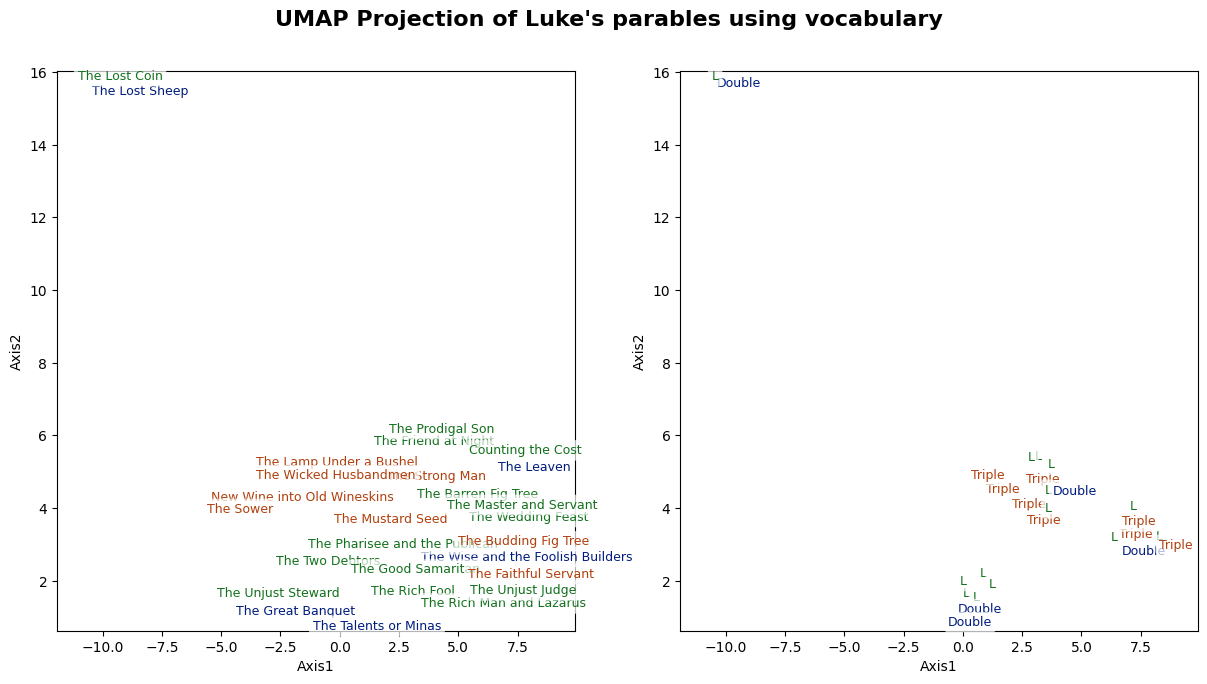

In [36]:
# Perform PCA on the vocabulary matrix
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import ConvexHull

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 8), constrained_layout=True)  # One row, two columns

# Apply UMAP
umap_ = umap.UMAP(n_components=2, n_neighbors=2, min_dist=0.1, metric="euclidean", random_state=42)
mt_df = frequency_df[frequency_df["book"] == "Lk"]

# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Perform PCA transformation
umap_components = umap_.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
umap_df = pd.DataFrame(data=umap_components, columns=["Axis1", "Axis2"])
umap_df["parable"] = mt_df["parable"].values
umap_df["labels"] = mt_df["cluster"].values
umap_df["source"] = mt_df["source"].values  # Only used for the second plot

# Generate a color palette
unique_labels = mt_df["source"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(umap_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = umap_df["Axis1"].min() - hull_padding, umap_df["Axis1"].max() + hull_padding
y_min, y_max = umap_df["Axis2"].min() - 0.2 * hull_padding, umap_df["Axis2"].max() + 0.2 * hull_padding

# ----------- First plot (labels = parables) -----------
ax = axes[0]
# Change alpha to 1 so that points are visible
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(umap_df.shape[0]):
    texts.append(ax.text(umap_df.Axis1[line], umap_df.Axis2[line],
                         umap_df.parable[line], horizontalalignment='left',
                         size=9, 
                         color=palette[umap_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = sources) -----------
ax = axes[1]
# Change alpha to 1 so that points are visible
p1 = sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(umap_df.shape[0]):
    texts.append(p1.text(umap_df.Axis1[line], umap_df.Axis2[line],
                         umap_df.source[line], horizontalalignment='left',
                         size=9,
                         color=palette[umap_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1))

# Save and show the figure
plt.suptitle(f"UMAP Projection of Luke's parables using vocabulary", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()

plt.savefig("figures/lk_vocabulary_pca_side_by_side.png", dpi=600)

plt.show()


/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/3030535159.py:89: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


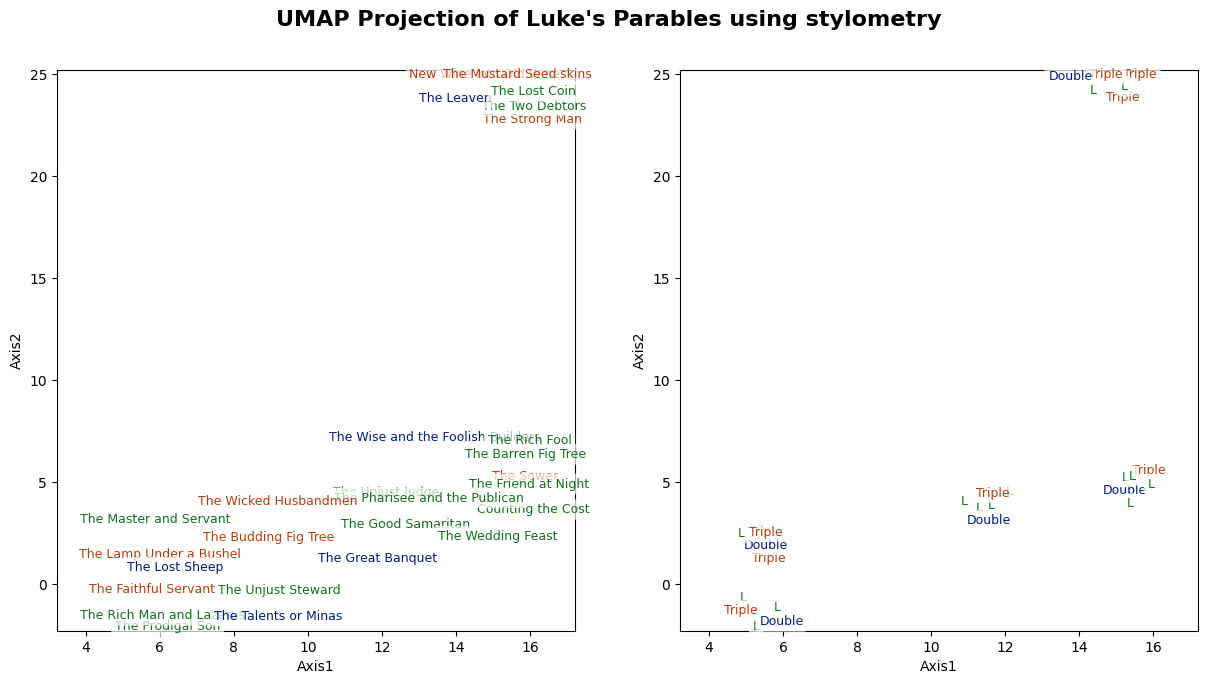

In [37]:
# Perform PCA on the vocabulary matrix
from sklearn.cluster import AgglomerativeClustering
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import ConvexHull

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 8), constrained_layout=True)  # One row, two columns

# Apply UMAP
umap_ = umap.UMAP(n_components=2, n_neighbors=5, min_dist=0.1, metric="euclidean", random_state=42)
mt_df = stylometry_df[stylometry_df["book"] == "Lk"]
mt_df = umap_.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
mt_df = pd.DataFrame(data=mt_df, columns=["Axis1", "Axis2"])
mt_df["parable"] = stylometry_df[stylometry_df["book"] == "Lk"]["parable"].values
mt_df["book"] = stylometry_df[stylometry_df["book"] == "Lk"]["book"].values
mt_df["source"] = stylometry_df[stylometry_df["book"] == "Lk"]["source"].values
mt_df["source_interpretation"] = stylometry_df[stylometry_df["book"] == "Lk"]["source_interpretation"].values

# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Perform PCA transformation
umap_components = umap_.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
umap_df = pd.DataFrame(data=umap_components, columns=["Axis1", "Axis2"])
umap_df["parable"] = mt_df["parable"].values
umap_df["labels"] = mt_df["cluster"].values
umap_df["source"] = mt_df["source"].values  # Only used for the second plot

# Generate a color palette
unique_labels = mt_df["source"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(umap_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = umap_df["Axis1"].min() - hull_padding, umap_df["Axis1"].max() + hull_padding
y_min, y_max = umap_df["Axis2"].min() - 0.2 * hull_padding, umap_df["Axis2"].max() + 0.2 * hull_padding

# ----------- First plot (labels = parables) -----------
ax = axes[0]
# Change alpha to 1 so that points are visible
sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(umap_df.shape[0]):
    texts.append(ax.text(umap_df.Axis1[line], umap_df.Axis2[line],
                         umap_df.parable[line], horizontalalignment='left',
                         size=9,
                         color=palette[umap_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = sources) -----------
ax = axes[1]
# Change alpha to 1 so that points are visible
p1 = sns.scatterplot(data=umap_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(umap_df.shape[0]):
    texts.append(p1.text(umap_df.Axis1[line], umap_df.Axis2[line],
                         umap_df.source[line], horizontalalignment='left',
                         size=9,
                         color=palette[umap_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1))

# Save and show the figure
plt.suptitle(f"UMAP Projection of Luke's Parables using stylometry", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()

plt.savefig("figures/lk_stylometry_pca_side_by_side.png", dpi=600)

plt.show()



/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/ComputationStyleCompanion/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


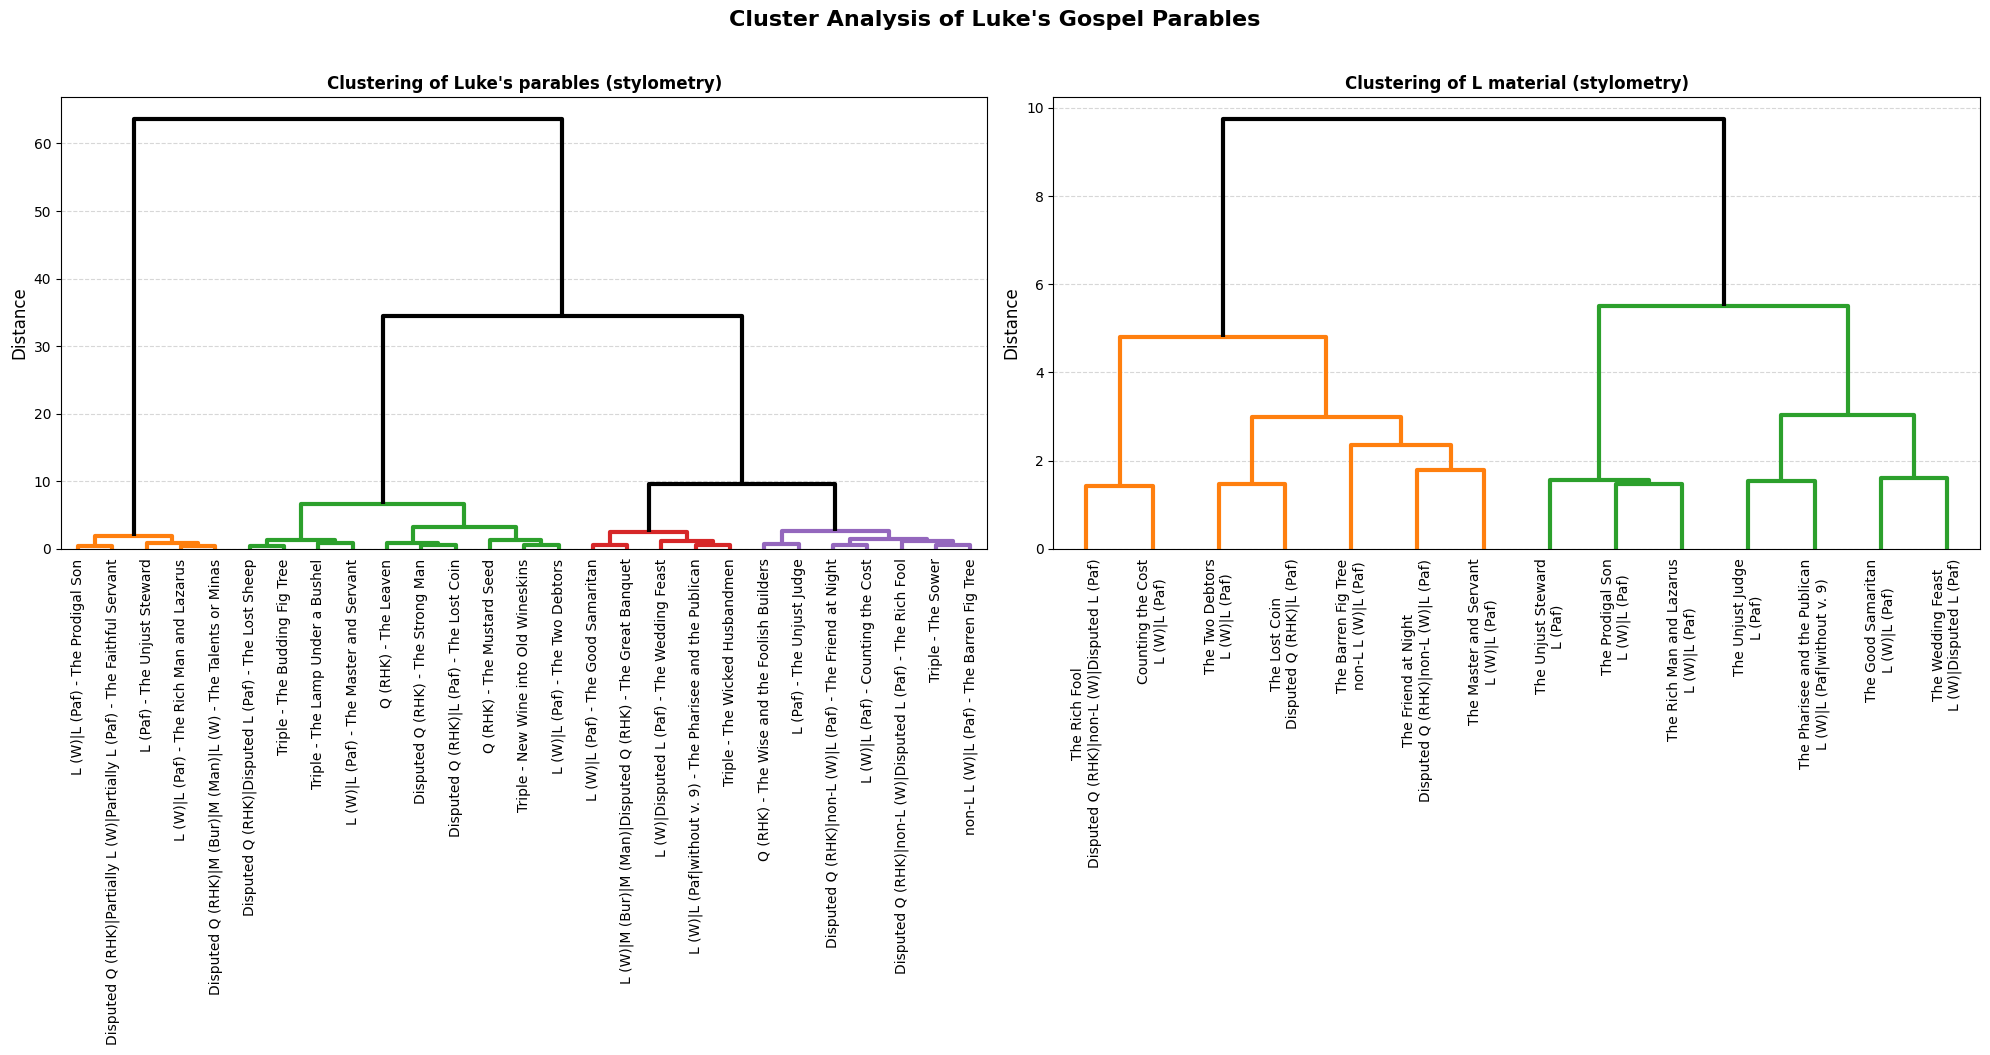

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Your stylometry_df should be defined already

# Set up the figure with two subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# First dendrogram (Clustering of Matthew's parables (stylometry))
lk_df = stylometry_df[(stylometry_df["book"] == "Lk")]
umap_ = umap.UMAP(n_components=5, n_neighbors=3, min_dist=0.1, metric="euclidean", random_state=42)
umap_components = umap_.fit_transform(lk_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Plot the first dendrogram (now showing "Clustering of Matthew's parables (stylometry)")
plot_dendrogram(
    umap_components,
    ax[0],  # Use the first subplot (ax[0])
    labels=[f"{"|".join(source_interpretation.replace("[", "").replace("]", "").replace("'", "").split(", ")[1:])} - {label}" if source_interpretation != "['Triple']" else f"Triple - {label}" for label, source_interpretation in zip(lk_df.parable.values, lk_df.source_interpretation.values)],
    title="Clustering of Luke's parables (stylometry)",
    linkage_="complete",
    distance_="manhattan",
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=9,
    show_leaf_counts=True,
    annotate_above=0
)

# Second dendrogram (Clustering of M material)
lk_df = stylometry_df[(stylometry_df["book"] == "Lk") & (stylometry_df["source"] == "L")]
umap_ = umap.UMAP(n_components=10, n_neighbors=5, min_dist=0.1, metric="euclidean", random_state=42)
umap_components = umap_.fit_transform(lk_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Plot the second dendrogram (now showing "Clustering of M material")
plot_dendrogram(
    umap_components,
    ax[1],  # Use the second subplot (ax[1])
    labels=[f"{label}\n{"|".join(source_interpretation.replace("[", "").replace("]", "").replace("'", "").split(", ")[1:])}" if source_interpretation != "['Triple']" else f"Triple - {label}" for label, source_interpretation in zip(lk_df.parable.values, lk_df.source_interpretation.values)],
    title="Clustering of L material (stylometry)",
    linkage_="complete",
    distance_="manhattan",
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=8,
    show_leaf_counts=True,
    annotate_above=0
)

plt.tight_layout()  # Adjust layout for better spacing
plt.suptitle("Cluster Analysis of Luke's Gospel Parables", fontweight='bold', fontsize=16, y=1.05)

plt.savefig("figures/lk_stylometry_dendrograms.png", dpi=600)
plt.show()



In [41]:
lk_df = stylometry_df[(stylometry_df["book"] == "Lk")]

umap_ = PCA(n_components=12)
umap_components = umap_.fit_transform(lk_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

selected_number_clusters = find_best_n_clusters(
    umap_components,
    min_clusters=2, metric='manhattan', linkage='complete')

hac = AgglomerativeClustering(n_clusters=3, linkage='complete', metric='manhattan')
hac.fit(umap_components)
lk_df["cluster"] = hac.labels_

print(lk_df.sort_values(by="cluster")[["cluster", "parable", "source_interpretation"]].to_latex(index=False))

\begin{tabular}{rll}
\toprule
cluster & parable & source_interpretation \\
\midrule
0 & The Wise and the Foolish Builders & ['Double', 'Q (RHK)'] \\
0 & The Budding Fig Tree & ['Triple'] \\
0 & The Great Banquet & ['Double', 'L (W)', 'M (Bur)', 'M (Man)', 'Disputed Q (RHK)'] \\
0 & The Wicked Husbandmen & ['Triple'] \\
0 & The Pharisee and the Publican & ['L', 'L (W)', 'L (Paf, without v. 9)'] \\
0 & The Unjust Judge & ['L', 'L (Paf)'] \\
0 & The Master and Servant & ['L', 'L (W)', 'L (Paf)'] \\
0 & The Lost Coin & ['L', 'Disputed Q (RHK)', 'L (Paf)'] \\
0 & The Lost Sheep & ['Double', 'Disputed Q (RHK)', 'Disputed L (Paf)'] \\
0 & The Wedding Feast & ['L', 'L (W)', 'Disputed L (Paf)'] \\
0 & The Leaven & ['Double', 'Q (RHK)'] \\
0 & Counting the Cost & ['L', 'L (W)', 'L (Paf)'] \\
0 & The Barren Fig Tree & ['L', 'non-L L (W)', 'L (Paf)'] \\
0 & The Rich Fool & ['L', 'Disputed Q (RHK)', 'non-L (W)', 'Disputed L (Paf)'] \\
0 & The Friend at Night & ['L', 'Disputed Q (RHK)', 'non-L (W)',

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/4017428626.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lk_df["cluster"] = hac.labels_


In [42]:
lk_df = stylometry_df[(stylometry_df["book"] == "Lk")]

umap_ = PCA(n_components=12)
umap_components = umap_.fit_transform(lk_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

selected_number_clusters = find_best_n_clusters(
    umap_components,
    min_clusters=2, metric='manhattan', linkage='complete')

hac = AgglomerativeClustering(n_clusters=4, linkage='complete', metric='manhattan')
hac.fit(umap_components)
lk_df["cluster"] = hac.labels_

print(((lk_df.groupby(["cluster","source"]).count()["parable"]/lk_df.groupby(["cluster"]).count()["parable"])*100).to_latex())
      
      

\begin{tabular}{llr}
\toprule
 &  & parable \\
cluster & source &  \\
\midrule
\multirow[t]{3}{*}{0} & Double & 18.181818 \\
 & L & 72.727273 \\
 & Triple & 9.090909 \\
\cline{1-3}
\multirow[t]{3}{*}{1} & Double & 25.000000 \\
 & L & 50.000000 \\
 & Triple & 25.000000 \\
\cline{1-3}
2 & L & 100.000000 \\
\cline{1-3}
\multirow[t]{3}{*}{3} & Double & 18.181818 \\
 & L & 27.272727 \\
 & Triple & 54.545455 \\
\cline{1-3}
\bottomrule
\end{tabular}



/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_32296/4281830792.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lk_df["cluster"] = hac.labels_
